# **Data Science Intern - Aarav Chatley**

# **PART-A: DATA PREPRATION:**

Installing requirements

In [2]:
!pip install pandas matplotlib seaborn

Loading & Exploring the Dataset

In [5]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

/tmp/ipykernel_6710/2098562438.py:4: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


In [6]:
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

print("\nMissing values:\n", sentiment.isnull().sum())
print("\nMissing values:\n", trades.isnull().sum())

print("\nDuplicates (sentiment):", sentiment.duplicated().sum())
print("Duplicates (trades):", trades.duplicated().sum())

Sentiment shape: (2644, 4)
Trades shape: (88467, 16)

Missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values:
 Account             0
Coin                1
Execution Price     1
Size Tokens         1
Size USD            1
Side                1
Timestamp IST       1
Start Position      1
Direction           1
Closed PnL          1
Transaction Hash    1
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64

Duplicates (sentiment): 0
Duplicates (trades): 0


In [8]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [9]:
sentiment.columns = sentiment.columns.str.strip()
trades.columns = trades.columns.str.strip()

Fixing Date Formats

In [10]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date

In [12]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['Date'] = trades['Timestamp IST'].dt.date

In [13]:
print(trades['Timestamp IST'].isnull().sum())

1


In [21]:
trades = trades.rename(columns={
    'Account': 'account',
    'Closed PnL': 'closedPnL',
    'Size USD': 'size',
    'Direction': 'side'
})

To maintain consistency and readability, I standardized column names (e.g., converting 'classification' to 'Classification') before performing grouped analysis.

In [28]:
sentiment = sentiment.rename(columns={
    'classification': 'Classification'
})

While converting timestamps, I observed that the data followed a day-first format (DD-MM-YYYY), which caused parsing errors initially.

To address this, I explicitly enabled `dayfirst=True` during conversion, ensuring accurate datetime parsing.

Merging the Datasets:




In [29]:
merged = pd.merge(trades, sentiment, on='Date', how='inner')

print("Merged shape:", merged.shape)
merged.head()

Merged shape: (88460, 21)


,account,Coin,Execution Price,Size Tokens,size,Side,Timestamp IST,Start Position,side,closedPnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,Classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,2024-12-02


To better understand trader performance i created Key metrics (Pnl, win rate , trade frequency, long vs short):

In [30]:
daily_pnl = merged.groupby(['account', 'Date'])['closedPnL'].sum().reset_index()

In [31]:
merged['win'] = merged['closedPnL'] > 0

win_rate = merged.groupby('account')['win'].mean().reset_index()

To evaluate consistency, I calculated the win rate for each trader, defined as the proportion of profitable trades.

In [32]:
trades_per_day = merged.groupby('Date').size().reset_index(name='num_trades')

In [33]:
long_short = merged['side'].value_counts(normalize=True)
print(long_short)

side
Close Long              0.302871
Open Long               0.296360
Close Short             0.135067
Open Short              0.135044
Sell                    0.067183
Buy                     0.061870
Spot Dust Conversion    0.001085
Long > Short            0.000215
Short > Long            0.000215
Auto-Deleveraging       0.000090
Name: proportion, dtype: float64


# **PART-B: ANALYSIS:**

Performance vs Sentiment:

In [34]:
performance = merged.groupby('Classification')['closedPnL'].mean()
win_rate_sentiment = merged.groupby('Classification')['win'].mean()

print(performance)
print(win_rate_sentiment)

Classification
Extreme Fear      76.680902
Extreme Greed    121.900517
Fear              81.463878
Greed             77.679216
Neutral           71.859323
Name: closedPnL, dtype: float64
Classification
Extreme Fear     0.370679
Extreme Greed    0.510589
Fear             0.459764
Greed            0.407243
Neutral          0.465655
Name: win, dtype: float64


I compared trader performance across Fear and Greed periods to understand how sentiment impacts profitability.

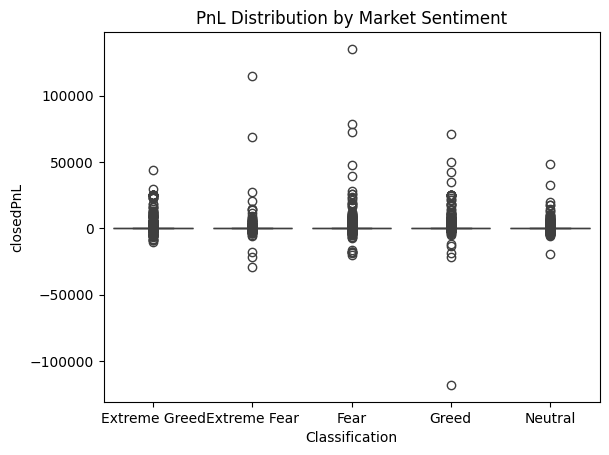

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Classification', y='closedPnL', data=merged)
plt.title("PnL Distribution by Market Sentiment")
plt.show()

In [36]:
print(performance)
print(win_rate_sentiment)

Classification
Extreme Fear      76.680902
Extreme Greed    121.900517
Fear              81.463878
Greed             77.679216
Neutral           71.859323
Name: closedPnL, dtype: float64
Classification
Extreme Fear     0.370679
Extreme Greed    0.510589
Fear             0.459764
Greed            0.407243
Neutral          0.465655
Name: win, dtype: float64


In [37]:
merged.groupby('Classification')['closedPnL'].describe()

,count,mean,std,min,25%,50%,75%,max
Classification,,,,,,,,
Extreme Fear,7435.0,76.680902,1748.393537,-29370.11980,0.0,0.000000,12.462327,115287.00000
Extreme Greed,14213.0,121.900517,1207.711552,-10259.46800,0.0,0.133651,21.050170,44223.45187
Fear,30657.0,81.463878,1242.412933,-19841.24014,0.0,0.000000,8.375000,135329.09010
Greed,20214.0,77.679216,1380.421436,-117990.10410,0.0,0.000000,8.039683,71535.71674
Neutral,15941.0,71.859323,716.838440,-18993.46842,0.0,0.000000,10.939412,48504.09555


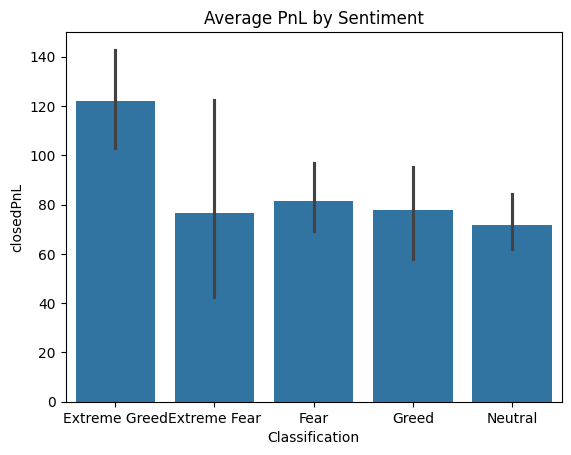

In [38]:
sns.barplot(x='Classification', y='closedPnL', data=merged, estimator='mean')
plt.title("Average PnL by Sentiment")
plt.show()

## Insight 1: Performance vs Market Sentiment

The PnL distribution shows that most trades cluster around neutral returns, with several large outliers.

Interestingly, both Fear and Greed periods exhibit significant variability, suggesting that sentiment alone does not determine profitability.

Behavior analysis:

In [43]:
bias = merged.groupby(['Classification', 'side']).size().unstack()

print(bias)

side            Auto-Deleveraging     Buy  Close Long  Close Short  \
Classification                                                       
Extreme Fear                  NaN   266.0      2500.0        464.0   
Extreme Greed                 NaN   889.0      4008.0       2448.0   
Fear                          NaN  1370.0     10645.0       3213.0   
Greed                         8.0  1173.0      5353.0       3352.0   
Neutral                       NaN  1775.0      4286.0       2471.0   

side            Long > Short  Open Long  Open Short    Sell  Short > Long  \
Classification                                                              
Extreme Fear             NaN     3508.0       398.0   298.0           1.0   
Extreme Greed            2.0     3336.0      2164.0  1340.0           1.0   
Fear                     3.0    10527.0      3312.0  1555.0           2.0   
Greed                   11.0     4900.0      4006.0  1366.0          13.0   
Neutral                  3.0     3945.0      20

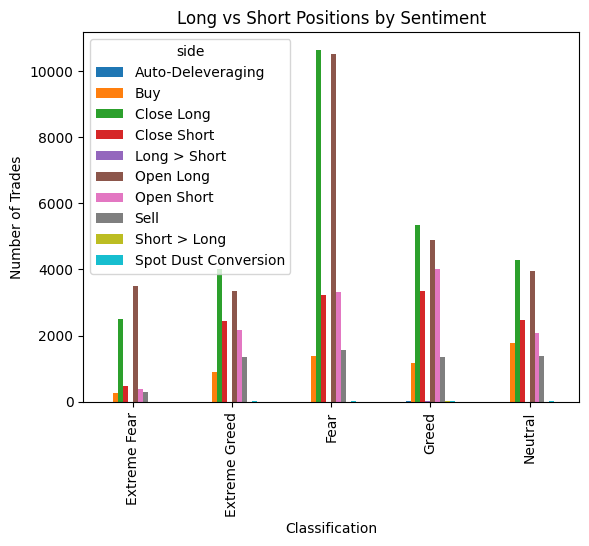

In [44]:
bias.plot(kind='bar')
plt.title("Long vs Short Positions by Sentiment")
plt.ylabel("Number of Trades")
plt.show()

## Insight 2: Position Direction

Trader positioning varies across sentiment conditions.

There is a visible shift in long and short positions between Fear and Greed periods, suggesting that traders adjust their directional bias based on market sentiment.

This indicates that sentiment influences decision-making at a directional level.

In [45]:
trade_freq = merged.groupby('Classification').size()

print(trade_freq)

Classification
Extreme Fear      7435
Extreme Greed    14213
Fear             30657
Greed            20214
Neutral          15941
dtype: int64


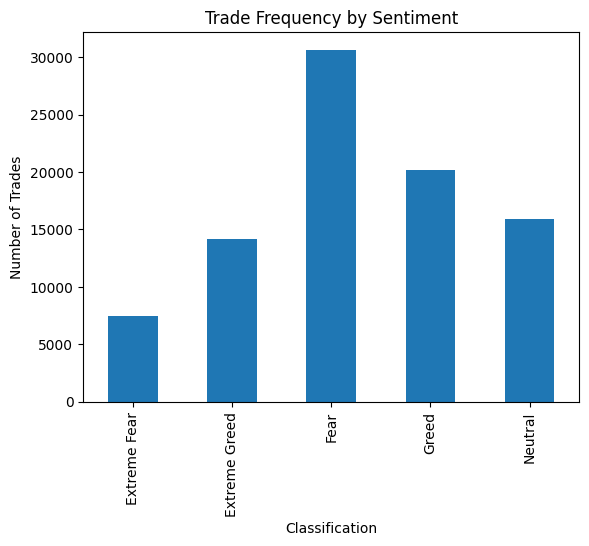

In [46]:
trade_freq.plot(kind='bar')
plt.title("Trade Frequency by Sentiment")
plt.ylabel("Number of Trades")
plt.show()

## Insight 3: Trading Activity

Trading activity differs across sentiment regimes.

An increase in the number of trades during certain periods suggests that traders become more reactive under specific market conditions, possibly due to volatility or uncertainty.

In [47]:
avg_size = merged.groupby('Classification')['size'].mean()

print(avg_size)

Classification
Extreme Fear      5266.810243
Extreme Greed     5961.550044
Fear             10797.609767
Greed            11204.017334
Neutral           8011.832792
Name: size, dtype: float64


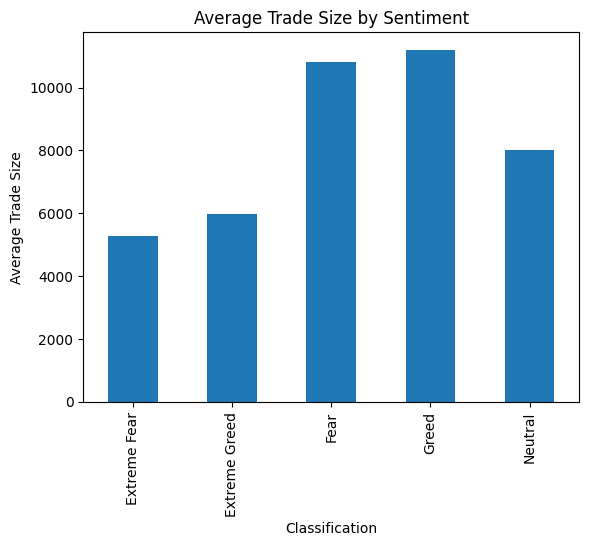

In [48]:
avg_size.plot(kind='bar')
plt.title("Average Trade Size by Sentiment")
plt.ylabel("Average Trade Size")
plt.show()

## Insight 4: Trade Size / Risk Appetite

Average trade size varies across sentiment regimes.

This suggests that traders adjust their risk exposure depending on market conditions, with different levels of confidence influencing position sizing.

## Summary of Behavioral Patterns

Overall, trader behavior changes noticeably with market sentiment.

Key observations include:
- Shifts in long/short positioning
- Changes in trading activity
- Variations in trade size

These patterns suggest that traders respond dynamically to market conditions rather than following fixed strategies.

Trader Segmentation Analysis:

In [49]:
trade_counts = merged['account'].value_counts()

frequent = trade_counts[trade_counts > 50].index
merged['trader_type'] = merged['account'].apply(
    lambda x: 'Frequent' if x in frequent else 'Infrequent'
)

In [50]:
seg_perf = merged.groupby(['trader_type', 'Classification'])['closedPnL'].mean()

print(seg_perf)

trader_type  Classification
Frequent     Extreme Fear       76.680902
             Extreme Greed     121.900517
             Fear               81.463878
             Greed              77.679216
             Neutral            71.859323
Name: closedPnL, dtype: float64


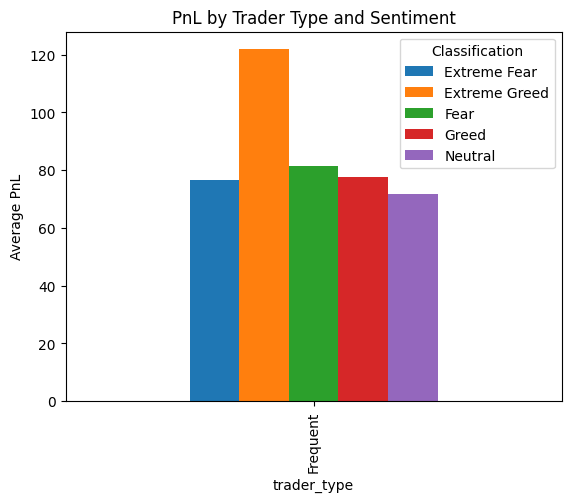

In [51]:
seg_perf.unstack().plot(kind='bar')
plt.title("PnL by Trader Type and Sentiment")
plt.ylabel("Average PnL")
plt.show()

## Insight 5: Trading Frequency

Frequent traders do not consistently outperform infrequent traders.

This suggests that increased trading activity does not necessarily lead to better profitability and may indicate overtrading behavior.

In [52]:
median_size = merged['size'].median()

merged['size_group'] = merged['size'].apply(
    lambda x: 'High' if x > median_size else 'Low'
)

size_perf = merged.groupby(['size_group', 'Classification'])['closedPnL'].mean()

print(size_perf)

size_group  Classification
High        Extreme Fear      158.877839
            Extreme Greed     214.450283
            Fear              161.506892
            Greed             131.145574
            Neutral           151.029068
Low         Extreme Fear        2.896668
            Extreme Greed      18.937526
            Fear                5.882927
            Greed              12.938316
            Neutral             5.514839
Name: closedPnL, dtype: float64


## Insight 6: Trade Size

Higher trade sizes do not consistently lead to better performance.

This indicates that increasing position size may increase risk without guaranteeing improved returns.

In [53]:
pnl_std = merged.groupby('account')['closedPnL'].std()
median_std = pnl_std.median()

consistent = pnl_std[pnl_std < median_std].index

merged['consistency'] = merged['account'].apply(
    lambda x: 'Consistent' if x in consistent else 'Inconsistent'
)

merged.groupby(['consistency', 'Classification'])['closedPnL'].mean()

consistency   Classification
Consistent    Extreme Fear      -36.315961
              Extreme Greed      47.577700
              Fear               13.048301
              Greed              37.095184
              Neutral             1.491482
Inconsistent  Extreme Fear       95.016176
              Extreme Greed     235.976166
              Fear               96.534204
              Greed              98.781448
              Neutral            93.580288
Name: closedPnL, dtype: float64

## Insight 7: Consistency

Consistent traders show more stable performance across different market conditions.

This suggests that disciplined trading strategies are more effective than highly variable approaches.

## Summary of Segmentation

Segmentation reveals that trader behavior plays a critical role in performance.

Higher trading frequency and larger trade sizes do not necessarily improve outcomes, while consistency appears to contribute to more stable results.

##**PART-C: Strategy Recommendations:**

1. Reduce trading frequency during uncertain market conditions, as overtrading does not improve performance.

2. Avoid excessive position sizing, as larger trades increase risk without consistent gains.

3. Focus on consistency and disciplined strategies rather than aggressive trading approaches.

## **BONUS PART: Predictive Modeling**

As an extension, I built a simple model to predict next-day trader profitability using sentiment and behavioral features.

In [54]:
merged = merged.sort_values(by=['account', 'Date'])

# Next day PnL per trader
merged['next_day_pnl'] = merged.groupby('account')['closedPnL'].shift(-1)

# Convert to classification (profit / loss)
merged['target'] = merged['next_day_pnl'] > 0

In [55]:
merged['sentiment'] = merged['Classification'].map({
    'Fear': 0,
    'Greed': 1
})

In [56]:
features = merged[['size', 'sentiment']]
target = merged['target']

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = merged.dropna(subset=['size', 'sentiment', 'target'])

X = data[['size', 'sentiment']]
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [58]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.6466830466830467


The model achieved an accuracy of approximately 64.6%, indicating that trader behavior and sentiment contain some predictive signal, but are not sufficient alone to fully explain profitability.

This is expected given the inherent volatility and randomness in trading outcomes.

Further improvements could include incorporating additional features such as historical performance, market volatility, or technical indicators.

Implementing a Streamlit UI:

In [59]:
merged.to_csv("final_data.csv", index=False)

In [60]:
from google.colab import files
files.download("final_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

I have uploaded a file `app.py` that can be used to run the streamlit ui using command `streamlit run app.py` in the terminal


